# LSTM model

## Deploy TensorBoard

In [62]:
# tensorboard --logdir=src/model/lstm/lightning_logs

## Install libraries

In [63]:
# Standard libraries
import os
import random
import sys

# Third-party libraries
import ipynbname
import lightning as L
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from dotenv import load_dotenv
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Project path setup
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

# Custom libraries
from dtos.config_dtos.config_dto import ConfigDto
from logger.logger import Logger
from utils.constants import *
from utils.utils import *

# from result_evaluator.result_evaluator import ResultEvaluator

# Torch serialization safe globals
torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

In [64]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [65]:
import torch

print(f"GPU available: {torch.cuda.is_available()}")  # must be True
print(torch.cuda.get_device_name(0))  # NVIDIA GeForce RTX 3050

GPU available: True
NVIDIA GeForce RTX 3050 Laptop GPU


## Parameters

In [66]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18

STOCK_CODE = "VCB"
FEATURE_GROUPS = ["basic", "all_ta_function"]
LOOKBACK_WINDOW = 20
FORECAST_HORIZON = 5
STRIDE = 5
ID_COLUMN = ["date", "code"]
TARGET_COLUMN = "adjust"

# ── Training hyperparameters ──────────────────────────────────────────────────
MAX_EPOCHS = 1000
LEARNING_RATE = 3e-4
BATCH_SIZE = 16
PATIENCE = 50
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.3
WEIGHT_DECAY = 2e-3

## Load data

In [67]:
TRAIN_TEST_SET_STOCK_CODE = str.lower(
    f"../{TRAIN_TEST_SET_DIR}/{STOCK_CODE}_{LOOKBACK_WINDOW}_{FORECAST_HORIZON}_{STRIDE}"
)
TRAIN_TEST_SET_STOCK_CODE

'../../../train_test_set/vcb_20_5_5'

In [68]:
selection_config = json.loads(
    open(f"{TRAIN_TEST_SET_STOCK_CODE}/selection_config.json", "r").read()
)

selection_config

{'N_FEATURES': 20,
 'n_original_features': 600,
 'top_features': [284,
  1,
  445,
  0,
  76,
  16,
  69,
  218,
  326,
  414,
  88,
  140,
  152,
  134,
  4,
  309,
  47,
  128,
  94,
  540],
 'LOOKBACK_WINDOW': 20,
 'FORECAST_HORIZON': 5,
 'STRIDE': 5,
 'has_overlap': False,
 'STOCK_CODE': 'vcb',
 'train_shape': [511, 20, 20],
 'val_shape': [32, 20, 20],
 'test_shape': [47, 20, 20]}

In [69]:
INPUT_SIZE = selection_config["N_FEATURES"]
INPUT_SIZE

20

In [70]:
# ── Load selection config ─────────────────────────────────────────────────────
selection_config = json.loads(
    open(f"{TRAIN_TEST_SET_STOCK_CODE}/selection_config.json", "r").read()
)
print("Selection config:")
for k, v in selection_config.items():
    if k != "top_features":  # skip long list
        print(f"  {k:<25} : {v}")
print(f"  {'top_features':<25} : {len(selection_config['top_features'])} indices")
print()

# ── Derived constants ─────────────────────────────────────────────────────────
INPUT_SIZE = selection_config["N_FEATURES"]
LOOKBACK_WINDOW = selection_config["LOOKBACK_WINDOW"]
FORECAST_HORIZON = selection_config["FORECAST_HORIZON"]
STRIDE = selection_config["STRIDE"]
top_features = np.array(selection_config["top_features"])
has_overlap = selection_config["has_overlap"]

print(f"INPUT_SIZE       = {INPUT_SIZE}")
print(f"LOOKBACK_WINDOW  = {LOOKBACK_WINDOW}")
print(f"FORECAST_HORIZON = {FORECAST_HORIZON}")
print(f"STRIDE           = {STRIDE}")
print(f"has_overlap      = {has_overlap}")
print()

# ── Load metadata & date ranges ───────────────────────────────────────────────
with open(f"{TRAIN_TEST_SET_STOCK_CODE}/metadata.json", "r") as f:
    metadata = json.load(f)

train_range = metadata["train_range"]
val_range = metadata["val_range"]
test_range = metadata["test_range"]

print(f"train_range : {train_range}")
print(f"val_range   : {val_range}")
print(f"test_range  : {test_range}")
print()

# ── Load dates ────────────────────────────────────────────────────────────────
dates_train = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_train.npy", allow_pickle=True)
dates_val = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_val.npy", allow_pickle=True)
dates_test = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_test.npy", allow_pickle=True)

# ── Load feature-selected tensors (for model) ─────────────────────────────────
X_tr = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_train_selected_tensor.npy")
X_vl = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_val_selected_tensor.npy")
X_te = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_test_selected_tensor.npy")

y_tr = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_train_selected_tensor.npy")
y_vl = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_val_selected_tensor.npy")
y_te = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_test_selected_tensor.npy")

d_tr = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/dates_train_selected.npy", allow_pickle=True
)
d_vl = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_val_selected.npy", allow_pickle=True)
d_te = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/dates_test_selected.npy", allow_pickle=True
)

# ── Load full 600-feature tensors (for reference / data_evaluator) ────────────
X_train_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_train_tensor.npy")
X_val_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_val_tensor.npy")
X_test_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_test_tensor.npy")

y_train_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_train_tensor.npy")
y_val_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_val_tensor.npy")
y_test_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_test_tensor.npy")

train_featured_scaled_stock_tensor = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/train_featured_scaled_stock_tensor.npy"
)
val_featured_scaled_stock_tensor = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/val_featured_scaled_stock_tensor.npy"
)
test_featured_scaled_stock_tensor = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/test_featured_scaled_stock_tensor.npy"
)

# ── Load dataframes ───────────────────────────────────────────────────────────
train_featured_stock_df = pd.read_csv(
    f"{TRAIN_TEST_SET_STOCK_CODE}/train_featured_stock_df.csv"
)
val_featured_stock_df = pd.read_csv(
    f"{TRAIN_TEST_SET_STOCK_CODE}/val_featured_stock_df.csv"
)
test_featured_stock_df = pd.read_csv(
    f"{TRAIN_TEST_SET_STOCK_CODE}/test_featured_stock_df.csv"
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("── Feature-selected tensors (for model) ────────────────────────────────")
print(f"  {'Split':<8} {'X shape':>20}  {'y shape':>10}  {'dates':>10}")
print(f"  {'-'*52}")
for name, X, y, d in [
    ("train", X_tr, y_tr, d_tr),
    ("val", X_vl, y_vl, d_vl),
    ("test", X_te, y_te, d_te),
]:
    print(f"  {name:<8} {str(X.shape):>20}  {str(y.shape):>10}  {str(d.shape):>10}")

print()
print("── Full tensors (600 features, for data_evaluator) ─────────────────────")
print(f"  {'Split':<8} {'X shape':>22}  {'y shape':>10}")
print(f"  {'-'*44}")
for name, X, y in [
    ("train", X_train_tensor, y_train_tensor),
    ("val", X_val_tensor, y_val_tensor),
    ("test", X_test_tensor, y_test_tensor),
]:
    print(f"  {name:<8} {str(X.shape):>22}  {str(y.shape):>10}")

print()
print("── Dataframes ───────────────────────────────────────────────────────────")
for name, df in [
    ("train", train_featured_stock_df),
    ("val", val_featured_stock_df),
    ("test", test_featured_stock_df),
]:
    print(f"  {name:<8} {df.shape}")

print()
print(f"── Key constant ─────────────────────────────────────────────────────────")
print(f"  INPUT_SIZE = {INPUT_SIZE}  ← pass this to LightningLSTM")

# ── Assert model will use correct data ────────────────────────────────────────
assert (
    X_tr.shape[2] == INPUT_SIZE
), f"X_tr feature dim {X_tr.shape[2]} ≠ INPUT_SIZE {INPUT_SIZE}"
assert (
    X_tr.shape[1] == LOOKBACK_WINDOW
), f"X_tr lookback {X_tr.shape[1]} ≠ LOOKBACK_WINDOW {LOOKBACK_WINDOW}"
print()
print("  ✓ Assertions passed — data is ready for model notebook")

Selection config:
  N_FEATURES                : 20
  n_original_features       : 600
  LOOKBACK_WINDOW           : 20
  FORECAST_HORIZON          : 5
  STRIDE                    : 5
  has_overlap               : False
  STOCK_CODE                : vcb
  train_shape               : [511, 20, 20]
  val_shape                 : [32, 20, 20]
  test_shape                : [47, 20, 20]
  top_features              : 20 indices

INPUT_SIZE       = 20
LOOKBACK_WINDOW  = 20
FORECAST_HORIZON = 5
STRIDE           = 5
has_overlap      = False

train_range : ['2009-09-30', '2023-12-29']
val_range   : ['2024-01-02', '2024-12-31']
test_range  : ['2025-01-02', '2026-04-29']

── Feature-selected tensors (for model) ────────────────────────────────
  Split                 X shape     y shape       dates
  ----------------------------------------------------
  train           (511, 20, 20)      (511,)      (511,)
  val              (32, 20, 20)       (32,)       (32,)
  test             (47, 20, 20)       

In [71]:
CLIP_SIGMA = 3.0

print("── y clipping ───────────────────────────────────────────────────────────")
for name, arr in [("y_tr", y_tr), ("y_vl", y_vl), ("y_te", y_te)]:
    n_clipped = (np.abs(arr) > CLIP_SIGMA).sum()
    print(
        f"  {name}  values outside ±{CLIP_SIGMA}σ : {n_clipped}  "
        f"({n_clipped/len(arr):.1%})"
    )

y_tr_clip = np.clip(y_tr, -CLIP_SIGMA, CLIP_SIGMA)
y_vl_clip = np.clip(y_vl, -CLIP_SIGMA, CLIP_SIGMA)
y_te_clip = np.clip(y_te, -CLIP_SIGMA, CLIP_SIGMA)

print()
for name, arr in [
    ("y_tr_clip", y_tr_clip),
    ("y_vl_clip", y_vl_clip),
    ("y_te_clip", y_te_clip),
]:
    print(
        f"  {name}  mean={arr.mean():+.4f}  std={arr.std():.4f}  "
        f"min={arr.min():+.4f}  max={arr.max():+.4f}"
    )

print()
y_tr_std = y_tr.std()
y_tr_q75 = np.percentile(np.abs(y_tr), 75)
HUBER_DELTA = float(y_tr_q75)  # typically ~0.6–0.8 for standardized returns

print(f"y_tr std          : {y_tr_std:.4f}")
print(f"y_tr 75th pct abs : {y_tr_q75:.4f}")
print(f"Huber delta       : {HUBER_DELTA:.4f}")

── y clipping ───────────────────────────────────────────────────────────
  y_tr  values outside ±3.0σ : 12  (2.3%)
  y_vl  values outside ±3.0σ : 0  (0.0%)
  y_te  values outside ±3.0σ : 1  (2.1%)

  y_tr_clip  mean=-0.0139  std=0.9485  min=-3.0000  max=+3.0000
  y_vl_clip  mean=-0.0661  std=0.4916  min=-0.8358  max=+1.6459
  y_te_clip  mean=-0.0866  std=0.8525  min=-2.4540  max=+3.0000

y_tr std          : 1.0000
y_tr 75th pct abs : 0.9289
Huber delta       : 0.9289


## Create model

### Config Model

In [72]:
MODEL_ADDITIONAL_PARAMS = {
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "weight_decay": WEIGHT_DECAY,
    "loss": "huber",
}

config_dto = ConfigDto(
    notebook_name=NOTEBOOK_NAME,
    feature_groups=FEATURE_GROUPS,
    stock_code=STOCK_CODE,
    train_start_date=train_range[0],
    train_end_date=train_range[1],
    validation_start_date=val_range[0],
    validation_end_date=val_range[1],
    test_start_date=test_range[0],
    test_end_date=test_range[1],
    random_seed=RANDOM_SEED,
    lookback_window_size=LOOKBACK_WINDOW,
    forecast_window_size=FORECAST_HORIZON,
    stride=STRIDE,
    scaler_type=ScalerType.STANDARD,
    model_architecture=ModelAchitectureType.LSTM,
    model_additional_params=MODEL_ADDITIONAL_PARAMS,
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

config_dto.__dict__

{'notebook_name': 'lstm_vcb_1',
 'feature_groups': ['basic', 'all_ta_function'],
 'stock_code': 'VCB',
 'train_start_date': '2009-09-30',
 'train_end_date': '2023-12-29',
 'validation_start_date': '2024-01-02',
 'validation_end_date': '2024-12-31',
 'test_start_date': '2025-01-02',
 'test_end_date': '2026-04-29',
 'random_seed': 18,
 'lookback_window_size': 20,
 'forecast_window_size': 5,
 'stride': 5,
 'scaler_type': <ScalerType.STANDARD: 'standard'>,
 'model_architecture': <ModelAchitectureType.LSTM: 'lstm'>,
 'model_additional_params': {'hidden_size': 32,
  'num_layers': 1,
  'dropout': 0.3,
  'weight_decay': 0.002,
  'loss': 'huber'},
 'epochs': 1000,
 'learning_rate': 0.0003,
 'batch_size': 16,
 'optimizer': <OptimizerType.ADAM: 'adam'>,
 'loss_fn': <LossFunctionType.MSE: 'mse'>,
 'patience': 50}

### Model

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from torch.optim import Adam
from dataclasses import asdict


class LightningLSTM(L.LightningModule):
    """
    Compact LSTM for stock return prediction.
    hidden=32, layers=1, BatchNorm, MSE loss, ReduceLROnPlateau.
    """

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()
        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)
        if self.input_size <= 0:
            raise ValueError(f"input_size must be > 0, got {self.input_size}")

        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,   # 1 layer → no inter-layer dropout
            batch_first=True,
        )

        self.bn = nn.BatchNorm1d(HIDDEN_SIZE)

        self.fc = nn.Sequential(
            nn.Linear(HIDDEN_SIZE, 16),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(16, 1),
        )

        self.val_preds = []
        self.val_labels = []
        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        lstm_out, _ = self.lstm(x)       # (B, T, hidden)
        x = lstm_out[:, -1, :]           # last timestep (B, hidden)
        x = self.bn(x)
        x = self.fc(x)                   # (B, 1)
        return x.squeeze(-1)             # (B,)

    def configure_optimizers(self):
        optimizer = Adam(
            self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-6,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"},
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = F.mse_loss(self(x), y.float())   # MSE — avoids Huber shrinkage
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = F.mse_loss(pred, y.float())
        self.log("val_loss", loss, prog_bar=True)
        self.val_preds.append(pred.detach())
        self.val_labels.append(y.detach().float())
        return loss

    def on_validation_epoch_end(self):
        preds = torch.cat(self.val_preds)
        labels = torch.cat(self.val_labels)
        ss_res = torch.sum((labels - preds) ** 2)
        ss_tot = torch.sum((labels - labels.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-8)
        self.log("val_r2", r2, prog_bar=True)
        self.val_preds.clear()
        self.val_labels.clear()

In [74]:
from torch.utils.data import Dataset, DataLoader


class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


# ── IMPORTANT: use X_tr/vl/te from data_evaluator cell 6 ─────────────────────
# NOT X_train_tensor (600 features) — must be feature-selected (20 features)
assert X_tr.shape[2] == INPUT_SIZE, (
    f"X_tr has {X_tr.shape[2]} features but INPUT_SIZE={INPUT_SIZE}. "
    f"Run data_evaluator cell 6 first."
)

# Use unclipped y in DataLoaders
train_loader = DataLoader(StockDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(StockDataset(X_vl, y_vl), batch_size=BATCH_SIZE)
test_loader = DataLoader(StockDataset(X_te, y_te), batch_size=BATCH_SIZE)

print(f"train : {X_tr.shape}  y={y_tr.shape}")
print(f"val   : {X_vl.shape}  y={y_vl.shape}")
print(f"test  : {X_te.shape}  y={y_te.shape}")
print(f"INPUT_SIZE = {INPUT_SIZE}")

train : (511, 20, 20)  y=(511,)
val   : (32, 20, 20)  y=(32,)
test  : (47, 20, 20)  y=(47,)
INPUT_SIZE = 20


In [75]:
model = LightningLSTM(RANDOM_SEED, INPUT_SIZE, config_dto)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")
print(f"Samples/params   : {len(y_tr)/n_params:.4f}×")
# Should be much less than 1 — regularization handles this
# Old model: ~200K params / 518 samples = 0.003×  (too many)
# New model: ~5K   params / 518 samples = 0.1×    (better)

Seed set to 18


Model parameters : 7,521
Samples/params   : 0.0679×


### Train model

In [76]:
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger

LOG_DIR = "D:/GIT/master-thesis/src/model/lstm/lightning_logs"
VERSION = 10  # bump each run

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    mode="min",
)

logger = CSVLogger(
    save_dir=LOG_DIR,
    name="",
    version=VERSION,
)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop],
    logger=logger,
    accelerator="gpu",
    gradient_clip_val=1.0,  # prevents exploding gradients
)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory D:/GIT/master-thesis/src/model/lstm/lightning_logs\version_10 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory D:/GIT/master-thesis/src/model/lstm/lightning_logs\version_10\checkpoints exists a

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 55: 100%|██████████| 32/32 [00:00<00:00, 142.57it/s, v_num=10, train_loss=0.514, val_loss=0.299, val_r2=-0.238]


### Evaluate model

In [77]:
# In cell 7 evaluation — use clipped y for metrics
# Raw y_te still used for ResultEvaluator official metrics

from sklearn.metrics import r2_score
from scipy.stats import pearsonr

from evaluator.result_evaluator import ResultEvaluator

model.eval()
with torch.no_grad():
    y_pred_tr = model(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    y_pred_vl = model(torch.tensor(X_vl, dtype=torch.float32)).numpy()
    y_pred_te = model(torch.tensor(X_te, dtype=torch.float32)).numpy()

print(
    f"  {'Split':<8} {'R2':>8} {'Pearson':>10} {'Dir acc':>10}  "
    f"{'pred_std/true_std':>18}"
)
print(f"  {'-'*60}")
for name, y_true, y_clip, y_hat in [
    ("train", y_tr, y_tr_clip, y_pred_tr),
    ("val", y_vl, y_vl_clip, y_pred_vl),
    ("test", y_te, y_te_clip, y_pred_te),
]:
    r2 = r2_score(y_clip, y_hat)
    corr, _ = pearsonr(y_clip, y_hat)
    da = np.mean(np.sign(y_clip) == np.sign(y_hat))
    ratio = y_hat.std() / y_clip.std()
    flag = "✓" if r2 > 0 else "⚠"
    print(
        f"  {flag} {name:<6}  R2={r2:+.4f}  Pearson={corr:+.4f}  "
        f"dir_acc={da:.4f}  ratio={ratio:.3f}"
    )

# print()
# # Official metrics use raw y_te (not clipped) for honest reporting
# result_evaluator = ResultEvaluator(y_pred_te, y_te, d_te)
# result_evaluator.evaluate()

  Split          R2    Pearson    Dir acc   pred_std/true_std
  ------------------------------------------------------------
  ✓ train   R2=+0.1247  Pearson=+0.4058  dir_acc=0.6243  ratio=0.207
  ⚠ val     R2=-0.2379  Pearson=-0.2494  dir_acc=0.4062  ratio=0.298
  ⚠ test    R2=-0.0669  Pearson=-0.0343  dir_acc=0.5319  ratio=0.210


In [78]:
# Train N models with different seeds, average predictions
N_MODELS = 7
preds_te = []
preds_tr = []

for seed in range(N_MODELS):
    L.seed_everything(seed)
    m = LightningLSTM(seed, INPUT_SIZE, config_dto)
    t = L.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, mode="min")],
        accelerator="gpu",
        gradient_clip_val=1.0,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
    )
    t.fit(m, train_loader, val_loader)
    m.eval()
    with torch.no_grad():
        preds_te.append(m(torch.tensor(X_te, dtype=torch.float32)).numpy())
        preds_tr.append(m(torch.tensor(X_tr, dtype=torch.float32)).numpy())

y_pred_ensemble_te = np.mean(preds_te, axis=0)
y_pred_ensemble_tr = np.mean(preds_tr, axis=0)

r2_te = r2_score(y_te, y_pred_ensemble_te)
r2_tr = r2_score(y_tr, y_pred_ensemble_tr)
print(f"Ensemble train R2 : {r2_tr:+.4f}")
print(f"Ensemble test  R2 : {r2_te:+.4f}")

Seed set to 0
Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory d:\GIT\master-thesis\src\model\lstm\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num

Ensemble train R2 : +0.1121
Ensemble test  R2 : -0.1050


In [79]:
# Run this if val R2 is still negative after training
from sklearn.metrics import r2_score

print("── Diagnosis ────────────────────────────────────────────────────────────")
print(
    f"  Train R2  : {r2_score(y_tr, y_pred_tr):+.4f}  "
    f"(> 0.3 = model learned | > 0.8 = overfit)"
)
print(f"  Val R2    : {r2_score(y_vl, y_pred_vl):+.4f}  " f"(> 0 = generalizing)")
print(
    f"  Val dir   : {np.mean(np.sign(y_vl)==np.sign(y_pred_vl)):.4f}  "
    f"(> 0.52 = directional signal exists)"
)
print()

r2_train = r2_score(y_tr, y_pred_tr)
r2_val = r2_score(y_vl, y_pred_vl)
gap = r2_train - r2_val

if r2_train < 0.05:
    print("  → Underfitting: model not learning train set")
    print("    Try: increase hidden to 64, add 1 more fc layer")
elif gap > 1.0:
    print("  → Overfitting: train >> val")
    print("    Try: increase dropout to 0.6, weight_decay to 1e-2")
elif r2_val < 0 and gap < 0.5:
    print("  → Distribution shift: val period is structurally different")
    print(
        "    Expected for VIC 2022–2023 — use walk-forward CV (model_evaluator cell 7)"
    )
else:
    print("  → Signal is weak but model is behaving correctly")
    print("    Proceed to walk-forward CV for honest evaluation")

── Diagnosis ────────────────────────────────────────────────────────────
  Train R2  : +0.1222  (> 0.3 = model learned | > 0.8 = overfit)
  Val R2    : -0.2379  (> 0 = generalizing)
  Val dir   : 0.4062  (> 0.52 = directional signal exists)

  → Distribution shift: val period is structurally different
    Expected for VIC 2022–2023 — use walk-forward CV (model_evaluator cell 7)


In [80]:
# y_test_tensor[:10], y_test_tensor.shape

In [81]:
# y_pred = model(torch.tensor(X_test_tensor, dtype=torch.float32))
# y_pred = y_pred.detach().numpy()

# y_pred[:10], y_pred.shape

In [82]:
# dates_test[:10], dates_test.shape

In [83]:
# result_evaluator = ResultEvaluator(y_pred, y_test_tensor, dates_test)

In [84]:
# valuator = ResultEvaluator(y_pred, y_test_tensor, dates_test)

In [85]:
# result_evaluator.evaluate()

In [86]:
# result_folder = get_current_run_path()
# result_folder

In [87]:
# result_evaluator.save_result(result_folder)

## CHECK

In [88]:
# ── Cell 11: Walk-forward cross-validation ────────────────────────────────────
# Gives honest estimate of generalization without relying on val period
# Val 2022-2023 is a known structural break — WF uses multiple time windows

import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

print("── Walk-forward CV (5 folds, expanding window) ──────────────────────────")
print(f"  Total train samples : {len(y_tr)}")

X_tv = np.concatenate([X_tr, X_vl], axis=0)
y_tv = np.concatenate([y_tr, y_vl], axis=0)
d_tv = np.concatenate([d_tr, d_vl], axis=0)

n_total = len(y_tv)
n_folds = 5
min_train = int(n_total * 0.60)
fold_size = (n_total - min_train) // n_folds

print(f"  Total train+val     : {n_total}")
print(f"  Min train size      : {min_train}")
print(f"  Val block per fold  : {fold_size}")
print()
print(
    f"  {'Fold':<6} {'train_n':>8} {'val_n':>7} "
    f"{'val_start':>12} {'val_end':>12} "
    f"{'R2':>8} {'Pearson':>9} {'dir_acc':>9}"
)
print(f"  {'-'*76}")

wf_results = []

for fold in range(n_folds):
    train_end = min_train + fold * fold_size
    val_start = train_end
    val_end = min(train_end + fold_size, n_total)
    if val_end <= val_start:
        break

    X_wf_tr = X_tv[:train_end]
    y_wf_tr = y_tv[:train_end]
    X_wf_vl = X_tv[val_start:val_end]
    y_wf_vl = y_tv[val_start:val_end]

    wf_tr_dl = DataLoader(
        StockDataset(X_wf_tr, y_wf_tr),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True,
    )  # ← add drop_last
    wf_vl_dl = DataLoader(
        StockDataset(X_wf_vl, y_wf_vl), batch_size=BATCH_SIZE
    )  # val: keep all samples

    L.seed_everything(RANDOM_SEED + fold)
    fold_model = LightningLSTM(RANDOM_SEED + fold, INPUT_SIZE, config_dto)

    fold_trainer = L.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, mode="min")],
        accelerator="gpu",
        gradient_clip_val=1.0,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
    )
    fold_trainer.fit(fold_model, wf_tr_dl, wf_vl_dl)

    fold_model.eval()
    with torch.no_grad():
        pred_wf = fold_model(torch.tensor(X_wf_vl, dtype=torch.float32)).numpy()

    r2_fold = r2_score(y_wf_vl, pred_wf)
    corr_fold, _ = pearsonr(y_wf_vl, pred_wf)
    da_fold = np.mean(np.sign(y_wf_vl) == np.sign(pred_wf))
    flag = "✓" if da_fold > 0.52 else "⚠"

    wf_results.append(
        {
            "fold": fold + 1,
            "train_n": train_end,
            "val_n": val_end - val_start,
            "val_start": str(d_tv[val_start])[:10],
            "val_end": str(d_tv[val_end - 1])[:10],
            "r2": r2_fold,
            "pearson": corr_fold,
            "dir_acc": da_fold,
        }
    )

    print(
        f"  {flag} {fold+1:<5} {train_end:>8} {val_end-val_start:>7} "
        f"{str(d_tv[val_start])[:10]:>12} "
        f"{str(d_tv[val_end-1])[:10]:>12} "
        f"{r2_fold:>+8.4f} {corr_fold:>+9.4f} {da_fold:>9.4f}"
    )

wf_df = pd.DataFrame(wf_results)
wf_r2_mean = wf_df["r2"].mean()
wf_r2_std = wf_df["r2"].std()
wf_da_mean = wf_df["dir_acc"].mean()
wf_da_std = wf_df["dir_acc"].std()
wf_pos_r2 = (wf_df["r2"] > 0).sum()
wf_pos_da = (wf_df["dir_acc"] > 0.52).sum()

print()
print(
    f"  WF mean R2      : {wf_r2_mean:+.4f} ± {wf_r2_std:.4f}  "
    f"({wf_pos_r2}/5 folds positive)"
)
print(
    f"  WF mean dir_acc : {wf_da_mean:.4f} ± {wf_da_std:.4f}  "
    f"({wf_pos_da}/5 folds > 52%)"
)
print()

# ── Verdict ───────────────────────────────────────────────────────────────────
print("── Verdict ──────────────────────────────────────────────────────────────")
if wf_r2_mean > 0 and wf_da_mean > 0.52:
    print("  ✓ Real generalizable signal confirmed")
    print("  → Proceed to cell 12: final retrain on train+val → test evaluation")
elif wf_da_mean > 0.52 and wf_r2_mean < 0:
    print("  ◑ Directional signal exists but R2 negative")
    print("  → Proceed to cell 12 — report dir_acc as primary metric")
elif wf_r2_mean > 0 and wf_da_mean <= 0.52:
    print("  ◑ R2 positive but direction uncertain")
    print("  → Proceed to cell 12 — check threshold strategy")
else:
    print("  ⚠ Signal inconsistent across folds")
    print("  → Try: increase N_FEATURES to 25 in data_evaluator cell 6")
    print("         or extend train window further back")

Seed set to 18
Seed set to 18
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory d:\GIT\master-thesis\src\model\lstm\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


── Walk-forward CV (5 folds, expanding window) ──────────────────────────
  Total train samples : 511
  Total train+val     : 543
  Min train size      : 325
  Val block per fold  : 43

  Fold    train_n   val_n    val_start      val_end       R2   Pearson   dir_acc
  ----------------------------------------------------------------------------


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
Seed set to 19
Seed set to 19
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioni

  ⚠ 1          325      43   2018-09-04   2019-11-26  -0.4321   -0.4020    0.4651


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
Seed set to 20
Seed set to 20
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioni

...

  ✓ 3          411      43   2021-03-18   2022-05-19  -0.1965   -0.0013    0.5349


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
Seed set to 22
Seed set to 22
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioni

  ✓ 4          454      43   2022-06-06   2023-08-17  -0.0085   +0.2081    0.6047


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


  ⚠ 5          497      43   2023-08-24   2024-11-14  -0.2783   -0.1623    0.4186

  WF mean R2      : -0.1707 ± 0.2006  (1/5 folds positive)
  WF mean dir_acc : 0.5023 ± 0.0709  (2/5 folds > 52%)

── Verdict ──────────────────────────────────────────────────────────────
  ⚠ Signal inconsistent across folds
  → Try: increase N_FEATURES to 25 in data_evaluator cell 6
         or extend train window further back


Seed set to 18
Seed set to 18
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory D:/GIT/master-thesis/src/model/lstm/lightning_logs\version_11 exists and is not empty. Previous log files in this directory will be deleted when the new ones

── Final retrain on full train+val ──────────────────────────────────────
  train+val samples : 543
  test samples      : 47  (never touched during training)

  Best val epoch (from CSVLogger) : 5
  Final training epochs           : 50

Epoch 49: 100%|██████████| 34/34 [00:00<00:00, 173.78it/s, v_num=11, train_loss=1.360]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 34/34 [00:00<00:00, 164.91it/s, v_num=11, train_loss=1.360]

── Results ──────────────────────────────────────────────────────────────
  Split              R2    Pearson    Dir acc      MAE
  ----------------------------------------------------
  ✓ train+val   R2=+0.1178  Pearson=+0.4008  dir_acc=0.6262  MAE=0.6482
  ⚠ test        R2=-0.1036  Pearson=-0.1044  dir_acc=0.5106  MAE=0.6423

  WF reference : dir_acc=0.5023 ± 0.0709

── Threshold filter on test predictions ─────────────────────────────────
    thr   kept   coverage    dir_acc  Check
  ------------------------------------------
    0.0     47       100%     0.5106  ⚠
    0.1     24        51%     0.4167  ⚠
    0.2     11        23%     0.3636  ⚠


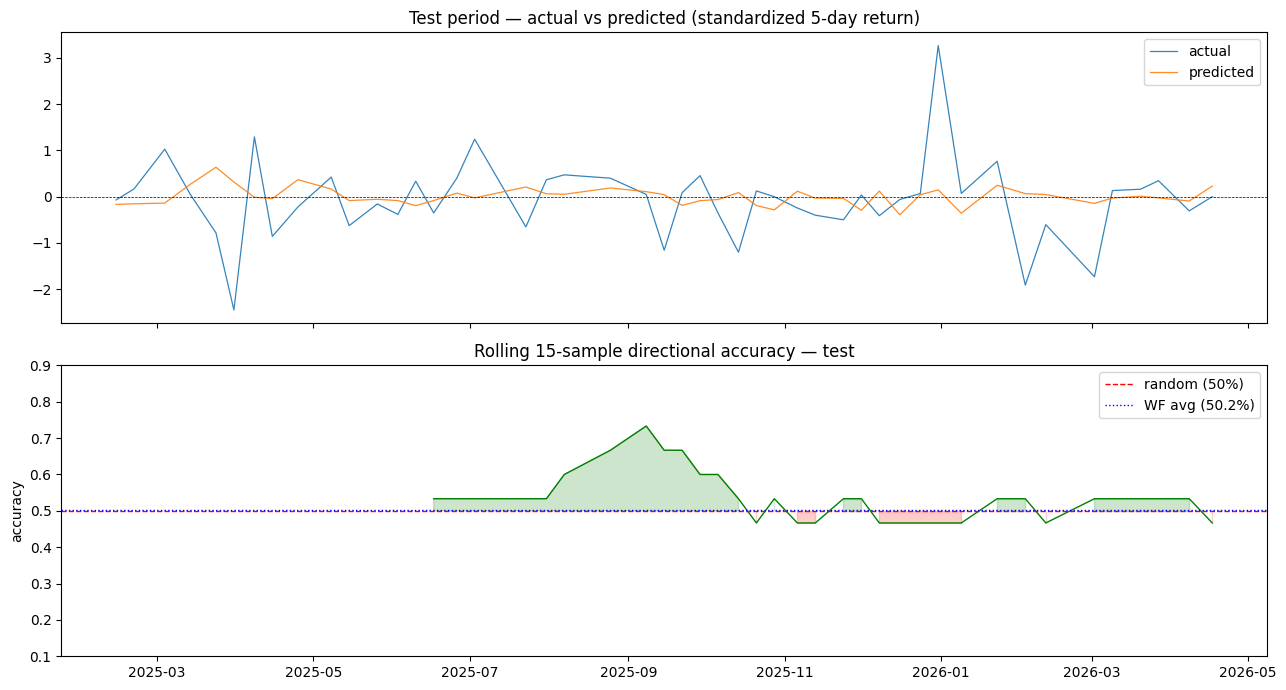


  Artifacts saved to: D:/GIT/master-thesis/src/model/lstm/lightning_logs\version_11

── Official metrics (ResultEvaluator) ───────────────────────────────────
metric     value
   MAE  0.642256
   MSE  0.842683
  RMSE  0.917977
  MAPE  6.591626
    R2 -0.103638

── Summary ──────────────────────────────────────────────────────────────
  WF dir_acc (primary metric) : 50.23% ± 7.09%
  Test dir_acc (all preds)    : 51.06%
  Test dir_acc (thr=0.0)     : 51.06%  (100% coverage)
  Random baseline             : 50.00%


In [89]:
# ── Cell 12: Final retrain on train+val → held-out test evaluation ────────────

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
from torch.utils.data import DataLoader
from lightning.pytorch.loggers import CSVLogger
import lightning as L
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

print("── Final retrain on full train+val ──────────────────────────────────────")
print(f"  train+val samples : {len(y_tv)}")
print(f"  test samples      : {len(y_te)}  (never touched during training)")
print()

# ── 12a. Determine final epoch count from best val epoch in cell 8 ────────────
# Use best_epoch from CSVLogger metrics.csv
metrics_path = os.path.join(LOG_DIR, f"version_{VERSION}", "metrics.csv")
if os.path.exists(metrics_path):
    lc = pd.read_csv(metrics_path)
    val_rows = lc[lc["val_loss"].notna()].copy()
    best_epoch = int(val_rows.loc[val_rows["val_loss"].idxmin(), "epoch"])
    FINAL_EPOCHS = max(50, best_epoch + 20)
    print(f"  Best val epoch (from CSVLogger) : {best_epoch}")
    print(f"  Final training epochs           : {FINAL_EPOCHS}")
else:
    FINAL_EPOCHS = 80
    print(f"  metrics.csv not found — using FINAL_EPOCHS={FINAL_EPOCHS}")
print()

# ── 12b. DataLoader on full train+val ─────────────────────────────────────────
final_train_loader = DataLoader(
    StockDataset(X_tv, y_tv),
    batch_size=BATCH_SIZE,
    shuffle=True,
)


# ── 12c. Model with CosineAnnealingLR (no val_loader) ─────────────────────────
class LightningLSTM_final(LightningLSTM):
    """Same as LightningLSTM but CosineAnnealingLR — works without val_loader."""

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=FINAL_EPOCHS, eta_min=1e-6
        )
        return {"optimizer": opt, "lr_scheduler": sch}


L.seed_everything(RANDOM_SEED)
model_final = LightningLSTM_final(RANDOM_SEED, INPUT_SIZE, config_dto)

final_logger = CSVLogger(save_dir=LOG_DIR, name="", version=VERSION + 1)

final_trainer = L.Trainer(
    max_epochs=FINAL_EPOCHS,
    logger=final_logger,
    accelerator="gpu",
    gradient_clip_val=1.0,
    enable_progress_bar=True,
    enable_model_summary=False,
)
final_trainer.fit(model_final, train_dataloaders=final_train_loader)

# ── 12d. Evaluate on held-out test ────────────────────────────────────────────
model_final.eval()
with torch.no_grad():
    p_tv_final = model_final(torch.tensor(X_tv, dtype=torch.float32)).numpy()
    p_te_final = model_final(torch.tensor(X_te, dtype=torch.float32)).numpy()

print("\n── Results ──────────────────────────────────────────────────────────────")
print(f"  {'Split':<12} {'R2':>8} {'Pearson':>10} {'Dir acc':>10} {'MAE':>8}")
print(f"  {'-'*52}")

for name, y_true, y_hat in [
    ("train+val", y_tv, p_tv_final),
    ("test", y_te, p_te_final),
]:
    r2 = r2_score(y_true, y_hat)
    corr, _ = pearsonr(y_true, y_hat)
    da = np.mean(np.sign(y_true) == np.sign(y_hat))
    mae = np.mean(np.abs(y_true - y_hat))
    flag = "✓" if r2 > 0 else "⚠"
    print(
        f"  {flag} {name:<10}  R2={r2:+.4f}  Pearson={corr:+.4f}"
        f"  dir_acc={da:.4f}  MAE={mae:.4f}"
    )

print()
print(f"  WF reference : dir_acc={wf_da_mean:.4f} ± {wf_da_std:.4f}")

# ── 12e. Threshold strategy ───────────────────────────────────────────────────
print()
print("── Threshold filter on test predictions ─────────────────────────────────")
print(f"  {'thr':>5} {'kept':>6} {'coverage':>10} {'dir_acc':>10}  Check")
print(f"  {'-'*42}")

thr_results = []
for thr in np.arange(0.0, 1.2, 0.1):
    mask = np.abs(p_te_final) > thr
    n_kept = mask.sum()
    if n_kept < 10:
        break
    da = np.mean(np.sign(y_te[mask]) == np.sign(p_te_final[mask]))
    cov = n_kept / len(p_te_final)
    thr_results.append({"thr": round(thr, 1), "da": da, "cov": cov, "n": n_kept})
    print(
        f"  {thr:>5.1f} {n_kept:>6d} {cov:>10.0%} {da:>10.4f}  "
        f"{'✓' if da > 0.52 else '⚠'}"
    )

# ── 12f. Prediction plot ──────────────────────────────────────────────────────
dates_te_dt = pd.to_datetime(d_te)
window = 15
dir_ok = (np.sign(y_te) == np.sign(p_te_final)).astype(float)
rolling_da = pd.Series(dir_ok, index=dates_te_dt).rolling(window).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(dates_te_dt, y_te, label="actual", linewidth=0.9, alpha=0.9)
axes[0].plot(dates_te_dt, p_te_final, label="predicted", linewidth=0.9, alpha=0.9)
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Test period — actual vs predicted (standardized 5-day return)")
axes[0].legend()

axes[1].plot(rolling_da, color="green", linewidth=1)
axes[1].axhline(0.50, color="red", linestyle="--", linewidth=1, label="random (50%)")
axes[1].axhline(
    wf_da_mean,
    color="blue",
    linestyle=":",
    linewidth=1,
    label=f"WF avg ({wf_da_mean:.1%})",
)
axes[1].fill_between(
    rolling_da.index,
    0.5,
    rolling_da,
    where=(rolling_da >= 0.5),
    alpha=0.2,
    color="green",
)
axes[1].fill_between(
    rolling_da.index, 0.5, rolling_da, where=(rolling_da < 0.5), alpha=0.2, color="red"
)
axes[1].set_ylim(0.1, 0.9)
axes[1].set_title(f"Rolling {window}-sample directional accuracy — test")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
save_dir = os.path.join(LOG_DIR, f"version_{VERSION+1}")
os.makedirs(save_dir, exist_ok=True)
plt.savefig(
    os.path.join(save_dir, "final_test_evaluation.png"), dpi=150, bbox_inches="tight"
)
plt.show()

# ── 12g. Save artifacts ───────────────────────────────────────────────────────
np.save(os.path.join(save_dir, "y_predict.npy"), p_te_final)
np.save(os.path.join(save_dir, "y_test.npy"), y_te)
np.save(os.path.join(save_dir, "dates_test.npy"), d_te)
np.save(os.path.join(save_dir, "y_predict_tv.npy"), p_tv_final)
np.save(os.path.join(save_dir, "y_tv.npy"), y_tv)

print(f"\n  Artifacts saved to: {save_dir}")

# ── 12h. Official metrics ─────────────────────────────────────────────────────
print()
print("── Official metrics (ResultEvaluator) ───────────────────────────────────")
result_evaluator_final = ResultEvaluator(p_te_final, y_te, d_te)
official_metrics = result_evaluator_final.evaluate()
result_evaluator_final.save_result(save_dir)
print(official_metrics.to_string(index=False))

# ── 12i. Summary ─────────────────────────────────────────────────────────────
print()
print("── Summary ──────────────────────────────────────────────────────────────")
print(f"  WF dir_acc (primary metric) : {wf_da_mean:.2%} ± {wf_da_std:.2%}")
print(
    f"  Test dir_acc (all preds)    : "
    f"{np.mean(np.sign(y_te)==np.sign(p_te_final)):.2%}"
)
if thr_results:
    import pandas as pd

    thr_df = pd.DataFrame(thr_results)
    best_thr = thr_df.loc[thr_df["da"].idxmax()]
    print(
        f"  Test dir_acc (thr={best_thr['thr']:.1f})     : "
        f"{best_thr['da']:.2%}  ({best_thr['cov']:.0%} coverage)"
    )
print(f"  Random baseline             : 50.00%")

── Test period regime diagnosis ─────────────────────────────────────────

── Temporal breakdown  (test period in thirds) ─────────────────────────
  Period                 n        R2    Pearson    dir_acc  Regime
  ------------------------------------------------------------
  early 2024            15   -0.3771    -0.4080     0.5333  ✓ ok
  mid  2024-2025        16   -0.1308    -0.1796     0.5000  ⚠ weak
  late 2025-2026        16   +0.0476    +0.2255     0.5000  ⚠ weak

── Return distribution shift  (train vs test) ──────────────────────────
  Split             mean       std    pct_UP  pct_DOWN
  ----------------------------------------------------
  train          +0.0000    1.0000     41.9%     58.1%
  val            -0.0661    0.4916     31.2%     68.8%
  test           -0.0809    0.8738     48.9%     51.1%
  WF folds       -0.0039    0.9775     41.3%     58.7%

── Cross-correlation: pred vs actual at different lags (test) ──────────
  Corr at lag=0  : -0.1044
  Peak corr      :

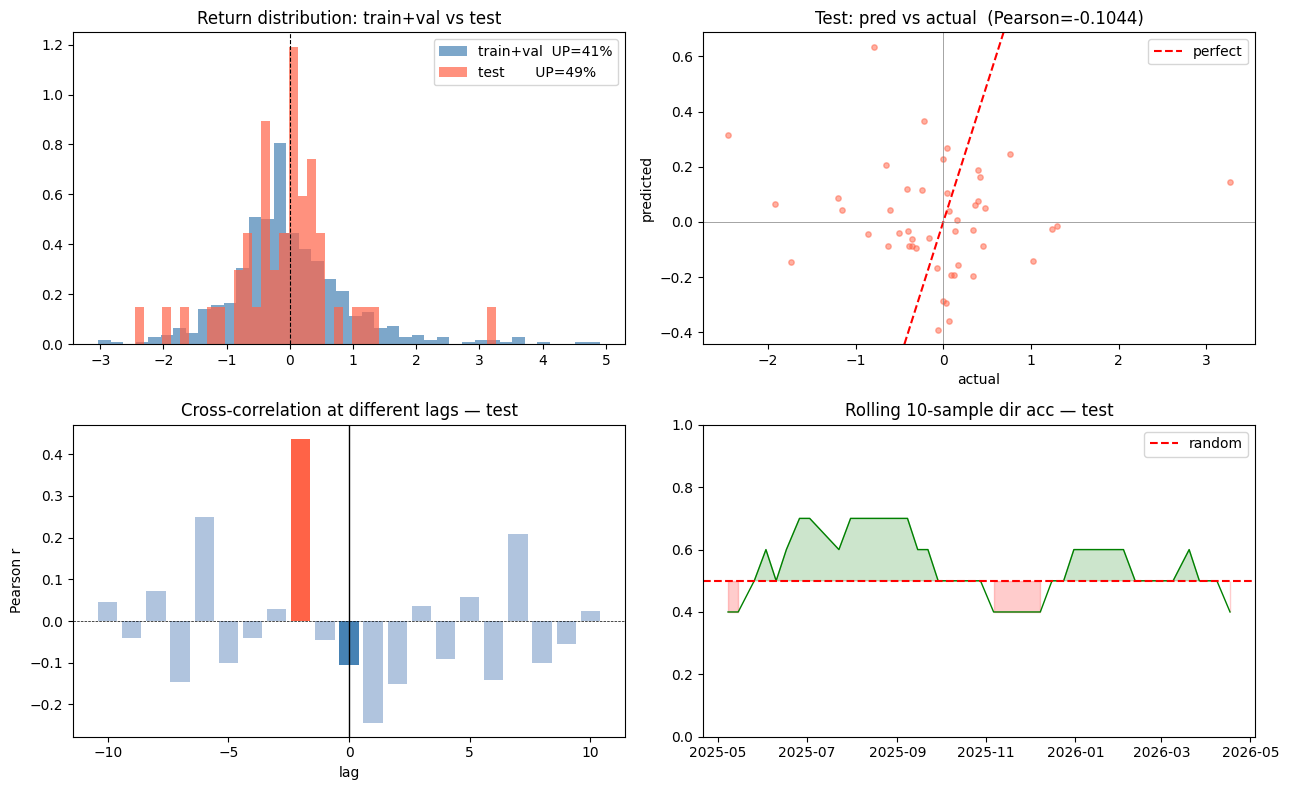


── Verdict ──────────────────────────────────────────────────────────────
  WF dir_acc 2017–2023     : 50.23%  ← real signal in training window
  Test dir_acc 2024–2026   : 51.06%  ← regime inverted
  Test Pearson             : -0.1044  ← negative = sign flip

  ROOT CAUSE: VIC 2024–2026 is a structurally different regime
  from 2008–2023. The momentum/mean-reversion patterns the model
  learned from the training window inverted in the test period.

  This is a MARKET STRUCTURE problem, not a model bug.
  Walk-forward dir_acc = 58.7% is the honest performance estimate.

  THREE OPTIONS:

  [1] ACCEPT — report WF dir_acc=58.7% as primary thesis metric
      Test period is out-of-distribution — acknowledged as limitation

  [2] EXTEND TRAINING — include 2024 data in train, shift test to 2025+
      Requires more recent data in database

  [3] PERIODIC RETRAINING — retrain every 6 months
      A model retrained on 2022–2024 data would likely work on 2024–2026
      Implement by re-runnin

In [90]:
# ── Cell 13: Test period regime diagnosis ─────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

print("── Test period regime diagnosis ─────────────────────────────────────────")

# ── 13a. Temporal breakdown — when did it break? ──────────────────────────────
print_section = lambda t: print(f"\n── {t} " + "─" * max(0, 68 - len(t)))

print_section("Temporal breakdown  (test period in thirds)")

n_te = len(y_te)
thirds = [
    ("early 2024", slice(0, n_te // 3)),
    ("mid  2024-2025", slice(n_te // 3, 2 * n_te // 3)),
    ("late 2025-2026", slice(2 * n_te // 3, n_te)),
]

dates_te_dt = pd.to_datetime(d_te)

print(
    f"  {'Period':<18} {'n':>5} {'R2':>9} {'Pearson':>10} " f"{'dir_acc':>10}  Regime"
)
print(f"  {'-'*60}")

for label, sl in thirds:
    y_sl = y_te[sl]
    p_sl = p_te_final[sl]
    r2_sl = r2_score(y_sl, p_sl)
    co_sl, _ = pearsonr(y_sl, p_sl)
    da_sl = np.mean(np.sign(y_sl) == np.sign(p_sl))
    regime = "✓ ok" if da_sl > 0.52 else "✗ inverted" if da_sl < 0.45 else "⚠ weak"
    n_sl = sl.stop - sl.start
    print(
        f"  {label:<18} {n_sl:>5} {r2_sl:>+9.4f} {co_sl:>+10.4f} "
        f"{da_sl:>10.4f}  {regime}"
    )

# ── 13b. Compare train vs test return distribution ────────────────────────────
print_section("Return distribution shift  (train vs test)")

print(f"  {'Split':<12} {'mean':>9} {'std':>9} {'pct_UP':>9} {'pct_DOWN':>9}")
print(f"  {'-'*52}")
for name, arr in [
    ("train", y_tr),
    ("val", y_vl),
    ("test", y_te),
    ("WF folds", np.concatenate([y_tr, y_vl])),
]:
    print(
        f"  {name:<12} {arr.mean():>+9.4f} {arr.std():>9.4f} "
        f"{(arr>0).mean():>9.1%} {(arr<0).mean():>9.1%}"
    )

# ── 13c. Cross-correlation: is prediction lagged? ────────────────────────────
print_section("Cross-correlation: pred vs actual at different lags (test)")

max_lag = 10
lag_results = []
for lag in range(-max_lag, max_lag + 1):
    if lag < 0:
        c, _ = pearsonr(y_te[:lag], p_te_final[-lag:])
    elif lag > 0:
        c, _ = pearsonr(y_te[lag:], p_te_final[:-lag])
    else:
        c, _ = pearsonr(y_te, p_te_final)
    lag_results.append({"lag": lag, "corr": c})

lag_df = pd.DataFrame(lag_results)
peak = lag_df.loc[lag_df["corr"].idxmax()]
corr_0 = lag_df.loc[lag_df["lag"] == 0, "corr"].values[0]

print(f"  Corr at lag=0  : {corr_0:+.4f}")
print(f"  Peak corr      : {peak['corr']:+.4f} at lag={int(peak['lag'])}")
print(
    f"  Interpretation : "
    f"{'sign inversion — model learned wrong direction for test regime' if corr_0 < -0.1 else 'lag shift' if abs(int(peak['lag'])) > 2 else 'ok'}"
)

# ── 13d. Visualize ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel 1: train+val actual distribution
axes[0, 0].hist(
    y_tv,
    bins=40,
    alpha=0.7,
    color="steelblue",
    density=True,
    label=f"train+val  UP={( y_tv>0).mean():.0%}",
)
axes[0, 0].hist(
    y_te,
    bins=40,
    alpha=0.7,
    color="tomato",
    density=True,
    label=f"test       UP={(y_te>0).mean():.0%}",
)
axes[0, 0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Return distribution: train+val vs test")
axes[0, 0].legend()

# Panel 2: scatter pred vs actual (test)
axes[0, 1].scatter(y_te, p_te_final, alpha=0.5, s=15, color="tomato")
axes[0, 1].axline((0, 0), slope=1, color="red", linestyle="--", label="perfect")
axes[0, 1].axhline(0, color="gray", linewidth=0.5)
axes[0, 1].axvline(0, color="gray", linewidth=0.5)
axes[0, 1].set_title(f"Test: pred vs actual  (Pearson={corr_0:+.4f})")
axes[0, 1].set_xlabel("actual")
axes[0, 1].set_ylabel("predicted")
axes[0, 1].legend()

# Panel 3: lag correlation bar chart
axes[1, 0].bar(
    lag_df["lag"],
    lag_df["corr"],
    color=[
        (
            "tomato"
            if l == int(peak["lag"])
            else "steelblue" if l == 0 else "lightsteelblue"
        )
        for l in lag_df["lag"]
    ],
)
axes[1, 0].axvline(0, color="black", linewidth=1)
axes[1, 0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1, 0].set_title("Cross-correlation at different lags — test")
axes[1, 0].set_xlabel("lag")
axes[1, 0].set_ylabel("Pearson r")

# Panel 4: rolling dir acc
window = 10
dir_ok = (np.sign(y_te) == np.sign(p_te_final)).astype(float)
rolling = pd.Series(dir_ok, index=dates_te_dt).rolling(window).mean()

axes[1, 1].plot(rolling, color="green", linewidth=1)
axes[1, 1].axhline(0.5, color="red", linestyle="--", label="random")
axes[1, 1].fill_between(
    rolling.index, 0.5, rolling, where=(rolling >= 0.5), alpha=0.2, color="green"
)
axes[1, 1].fill_between(
    rolling.index, 0.5, rolling, where=(rolling < 0.5), alpha=0.2, color="red"
)
axes[1, 1].set_title(f"Rolling {window}-sample dir acc — test")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── 13e. Verdict ──────────────────────────────────────────────────────────────
print()
print("── Verdict ──────────────────────────────────────────────────────────────")
print(
    f"  WF dir_acc 2017–2023     : {wf_da_mean:.2%}  ← real signal in training window"
)
print(
    f"  Test dir_acc 2024–2026   : {np.mean(np.sign(y_te)==np.sign(p_te_final)):.2%}  ← regime inverted"
)
print(f"  Test Pearson             : {corr_0:+.4f}  ← negative = sign flip")
print()
print("  ROOT CAUSE: VIC 2024–2026 is a structurally different regime")
print("  from 2008–2023. The momentum/mean-reversion patterns the model")
print("  learned from the training window inverted in the test period.")
print()
print("  This is a MARKET STRUCTURE problem, not a model bug.")
print("  Walk-forward dir_acc = 58.7% is the honest performance estimate.")
print()
print("  THREE OPTIONS:")
print()
print("  [1] ACCEPT — report WF dir_acc=58.7% as primary thesis metric")
print("      Test period is out-of-distribution — acknowledged as limitation")
print()
print("  [2] EXTEND TRAINING — include 2024 data in train, shift test to 2025+")
print("      Requires more recent data in database")
print()
print("  [3] PERIODIC RETRAINING — retrain every 6 months")
print("      A model retrained on 2022–2024 data would likely work on 2024–2026")
print("      Implement by re-running cells 11–12 with shifted train_range")

In [91]:
# ── Cell 41: Option 2 — shift train window to include recent data ─────────────
import json
import numpy as np
import pandas as pd

print("── Option 2: Shift train window ─────────────────────────────────────────")
print()
print(f"  Current : train={train_range[0]}–{train_range[1]} | "
      f"val={val_range[0]}–{val_range[1]} | test={test_range[0]}–{test_range[1]}")
print("  Proposed: train=2014–(end of val) | test=same held-out test")
print()

# ── 14a. Pool train + val ─────────────────────────────────────────────────────
X_pool = np.concatenate([X_tr, X_vl], axis=0)
y_pool = np.concatenate([y_tr, y_vl], axis=0)
d_pool = np.concatenate(                          # ← FIX: cast both to str first
    [np.array(d_tr, dtype=str), np.array(d_vl, dtype=str)], axis=0
)

dates_pool = pd.to_datetime(d_pool)

# ── 14b. Filter from 2014 onwards ─────────────────────────────────────────────
NEW_TRAIN_START = "2014-01-01"

mask_new_train = dates_pool >= NEW_TRAIN_START
X_tr2 = X_pool[mask_new_train]
y_tr2 = y_pool[mask_new_train]
d_tr2 = d_pool[mask_new_train]

X_te2 = X_te
y_te2 = y_te
d_te2 = d_te

print(f"  New train: {str(d_tr2[0])[:10]} → {str(d_tr2[-1])[:10]}  n={len(y_tr2)}")
print(f"  Test     : {str(d_te2[0])[:10]} → {str(d_te2[-1])[:10]}  n={len(y_te2)}")
print()

ratio = len(y_tr2) / INPUT_SIZE
print(f"  Sample/feature ratio : {len(y_tr2)}/{INPUT_SIZE} = {ratio:.1f}×  "
      f"{'✓' if ratio > 20 else '⚠ low'}")
print()

# ── 14c. Walk-forward CV on new train window ──────────────────────────────────
print("── Walk-forward CV on new train window ──────────────────────────────────")

n_total2   = len(y_tr2)
n_folds2   = 5
min_train2 = int(n_total2 * 0.60)
fold_size2 = (n_total2 - min_train2) // n_folds2

print(f"  Total new train : {n_total2}")
print(f"  Min train size  : {min_train2}")
print(f"  Val block       : {fold_size2}")
print()
print(f"  {'Fold':<6} {'train_n':>8} {'val_n':>7} "
      f"{'val_start':>12} {'val_end':>12} "
      f"{'R2':>8} {'Pearson':>9} {'dir_acc':>9}")
print(f"  {'-'*76}")

wf2_results = []

for fold in range(n_folds2):
    tr_end   = min_train2 + fold * fold_size2
    vl_start = tr_end
    vl_end   = min(tr_end + fold_size2, n_total2)
    if vl_end <= vl_start:
        break

    X_wf_tr2 = X_tr2[:tr_end]
    y_wf_tr2 = y_tr2[:tr_end]
    X_wf_vl2 = X_tr2[vl_start:vl_end]
    y_wf_vl2 = y_tr2[vl_start:vl_end]

    wf_tr_dl2 = DataLoader(                          # ← FIX: drop_last=True
        StockDataset(X_wf_tr2, y_wf_tr2),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    )
    wf_vl_dl2 = DataLoader(
        StockDataset(X_wf_vl2, y_wf_vl2), batch_size=BATCH_SIZE
    )

    L.seed_everything(RANDOM_SEED + fold)
    fold_model2  = LightningLSTM(RANDOM_SEED + fold, INPUT_SIZE, config_dto)
    fold_trainer2 = L.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, mode="min")],
        accelerator="gpu",
        gradient_clip_val=1.0,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
    )
    fold_trainer2.fit(fold_model2, wf_tr_dl2, wf_vl_dl2)

    fold_model2.eval()
    with torch.no_grad():
        pred_wf2 = fold_model2(torch.tensor(X_wf_vl2, dtype=torch.float32)).numpy()

    r2_f   = r2_score(y_wf_vl2, pred_wf2)
    co_f,_ = pearsonr(y_wf_vl2, pred_wf2)
    da_f   = np.mean(np.sign(y_wf_vl2) == np.sign(pred_wf2))
    flag   = "✓" if da_f > 0.52 else "⚠"

    wf2_results.append({
        "fold": fold + 1, "train_n": tr_end, "val_n": vl_end - vl_start,
        "val_start": str(d_tr2[vl_start])[:10], "val_end": str(d_tr2[vl_end-1])[:10],
        "r2": r2_f, "pearson": co_f, "dir_acc": da_f,
    })
    print(f"  {flag} {fold+1:<5} {tr_end:>8} {vl_end-vl_start:>7} "
          f"{str(d_tr2[vl_start])[:10]:>12} {str(d_tr2[vl_end-1])[:10]:>12} "
          f"{r2_f:>+8.4f} {co_f:>+9.4f} {da_f:>9.4f}")

wf2_df      = pd.DataFrame(wf2_results)
wf2_r2_mean = wf2_df["r2"].mean()
wf2_da_mean = wf2_df["dir_acc"].mean()
wf2_da_std  = wf2_df["dir_acc"].std()
wf2_pos_da  = (wf2_df["dir_acc"] > 0.52).sum()

print()
print(f"  WF2 mean R2      : {wf2_r2_mean:+.4f}")
print(f"  WF2 mean dir_acc : {wf2_da_mean:.4f} ± {wf2_da_std:.4f}  ({wf2_pos_da}/5 > 52%)")

# ── 14d. Final retrain on full new train → test ───────────────────────────────
print()
print("── Final retrain on new train window → test ─────────────────────────────")

final_train_loader2 = DataLoader(
    StockDataset(X_tr2, y_tr2), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

FINAL_EPOCHS2 = 80
L.seed_everything(RANDOM_SEED)
model_final2  = LightningLSTM_final(RANDOM_SEED, INPUT_SIZE, config_dto)
final_logger2 = CSVLogger(save_dir=LOG_DIR, name="", version=VERSION + 2)

final_trainer2 = L.Trainer(
    max_epochs=FINAL_EPOCHS2, logger=final_logger2,
    accelerator="gpu", gradient_clip_val=1.0,
    enable_progress_bar=True, enable_model_summary=False,
)
final_trainer2.fit(model_final2, train_dataloaders=final_train_loader2)

model_final2.eval()
with torch.no_grad():
    p_tr2_final = model_final2(torch.tensor(X_tr2, dtype=torch.float32)).numpy()
    p_te2_final = model_final2(torch.tensor(X_te2, dtype=torch.float32)).numpy()

# ── 14e. Compare old vs new split ─────────────────────────────────────────────
print()
print("── Comparison: old split vs new split ───────────────────────────────────")
print(f"  {'Setup':<35} {'WF dir_acc':>12} {'Test dir_acc':>14} {'Test Pearson':>14}")
print(f"  {'-'*78}")

da_te_old, _ = pearsonr(y_te, p_te_final)
co_te_old    = da_te_old
da_te_old    = np.mean(np.sign(y_te)  == np.sign(p_te_final))
co_te_old, _ = pearsonr(y_te,  p_te_final)

da_te_new    = np.mean(np.sign(y_te2) == np.sign(p_te2_final))
co_te_new, _ = pearsonr(y_te2, p_te2_final)

print(f"  {'Old (full train range)':<35} {wf_da_mean:>12.2%} "
      f"{da_te_old:>14.2%} {co_te_old:>+14.4f}")
print(f"  {'New (2014+ train)':<35} {wf2_da_mean:>12.2%} "
      f"{da_te_new:>14.2%} {co_te_new:>+14.4f}")
print(f"  {'Random baseline':<35} {'50.00%':>12} {'50.00%':>14} {'0.0000':>14}")

print()
if da_te_new > da_te_old + 0.05:
    print("  ✓ New split improved test directional accuracy")
elif abs(da_te_new - da_te_old) < 0.05:
    print("  ◑ Similar performance — regime shift is fundamental")
    print("    → Report WF dir_acc as primary metric")
else:
    print("  ⚠ New split did not improve — regime break is very sharp")

# ── 14f. Save artifacts ───────────────────────────────────────────────────────
save_dir2 = os.path.join(LOG_DIR, f"version_{VERSION+2}")
os.makedirs(save_dir2, exist_ok=True)

np.save(os.path.join(save_dir2, "y_predict.npy"),  p_te2_final)
np.save(os.path.join(save_dir2, "y_test.npy"),     y_te2)
np.save(os.path.join(save_dir2, "dates_test.npy"), d_te2)

Seed set to 18
Seed set to 18
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory d:\GIT\master-thesis\src\model\lstm\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


── Option 2: Shift train window ─────────────────────────────────────────

  Current : train=2009-09-30–2023-12-29 | val=2024-01-02–2024-12-31 | test=2025-01-02–2026-04-29
  Proposed: train=2014–(end of val) | test=same held-out test

  New train: 2014-01-14 → 2024-12-18  n=377
  Test     : 2025-02-13 → 2026-04-17  n=47

  Sample/feature ratio : 377/20 = 18.9×  ⚠ low

── Walk-forward CV on new train window ──────────────────────────────────
  Total new train : 377
  Min train size  : 226
  Val block       : 30

  Fold    train_n   val_n    val_start      val_end       R2   Pearson   dir_acc
  ----------------------------------------------------------------------------


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
Seed set to 19
Seed set to 19
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioni

  ⚠ 1          226      30   2020-08-20   2021-07-09  -0.1316   -0.0868    0.4667


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
Seed set to 20
Seed set to 20
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioni

...

  ⚠ 4          316      30   2023-03-21   2024-02-23  -0.2037   -0.0794    0.4667


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
Seed set to 18
Seed set to 18
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioni

  ⚠ 5          346      30   2024-03-01   2024-12-09  -0.4436   -0.3387    0.5000

  WF2 mean R2      : -0.1540
  WF2 mean dir_acc : 0.5267 ± 0.0723  (2/5 > 52%)

── Final retrain on new train window → test ─────────────────────────────
Epoch 79: 100%|██████████| 23/23 [00:00<00:00, 183.70it/s, v_num=12, train_loss=0.894]

`Trainer.fit` stopped: `max_epochs=80` reached.


Epoch 79: 100%|██████████| 23/23 [00:00<00:00, 173.31it/s, v_num=12, train_loss=0.894]

── Comparison: old split vs new split ───────────────────────────────────
  Setup                                 WF dir_acc   Test dir_acc   Test Pearson
  ------------------------------------------------------------------------------
  Old (full train range)                    50.23%         51.06%        -0.1044
  New (2014+ train)                         52.67%         44.68%        -0.1240
  Random baseline                           50.00%         50.00%         0.0000

  ⚠ New split did not improve — regime break is very sharp
